# Credit Card Fraud Detection

### XGBoost + SMOTE + Decision Threshold Tuning

This notebook demonstrates fraud detection on a heavily imbalanced synthetic transaction dataset and compares XGBoost against a baseline SVM.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

np.random.seed(42)

## 1. Create the synthetic imbalanced transaction dataset

The dataset has 3,000 transactions and only 60 fraud cases (2% fraud), so the classes are heavily imbalanced.

In [2]:
rng = np.random.default_rng(42)
n = 3000
fraud_n = 60

y = np.zeros(n, dtype=int)
fraud_index = rng.choice(n, fraud_n, replace=False)
y[fraud_index] = 1

amount = np.where(y == 1, rng.lognormal(4.8, 0.9, n), rng.lognormal(4.3, 0.8, n))
time_since_last_txn = np.where(y == 1, rng.exponential(8, n), rng.exponential(24, n))
transactions_24h = np.where(y == 1, rng.poisson(5, n) + 1, rng.poisson(2, n))
avg_amount_7d = np.where(y == 1, rng.lognormal(4.2, 0.7, n), rng.lognormal(4.0, 0.6, n))
device_risk = np.where(y == 1, rng.beta(4, 3, n), rng.beta(2, 6, n))
location_distance_km = np.where(y == 1, rng.gamma(3, 30, n), rng.gamma(2, 15, n))
merchant_risk = np.where(y == 1, rng.beta(4, 3, n), rng.beta(2, 5, n))
account_age_days = np.where(y == 1, rng.integers(30, 1200, n), rng.integers(30, 3000, n))
is_international = np.where(y == 1, rng.binomial(1, 0.35, n), rng.binomial(1, 0.08, n))
is_new_device = np.where(y == 1, rng.binomial(1, 0.35, n), rng.binomial(1, 0.05, n))

df = pd.DataFrame({
    "amount": amount,
    "time_since_last_txn": time_since_last_txn,
    "transactions_24h": transactions_24h,
    "avg_amount_7d": avg_amount_7d,
    "device_risk": device_risk,
    "location_distance_km": location_distance_km,
    "merchant_risk": merchant_risk,
    "account_age_days": account_age_days,
    "is_international": is_international,
    "is_new_device": is_new_device,
    "is_fraud": y
})

print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df["is_fraud"].value_counts())
print("\nFraud percentage:", round(df["is_fraud"].mean() * 100, 2), "%")
df.head()

Dataset shape: (3000, 11)

Class distribution:
is_fraud
0    2940
1      60
Name: count, dtype: int64

Fraud percentage: 2.0 %


,amount,time_since_last_txn,transactions_24h,avg_amount_7d,device_risk,location_distance_km,merchant_risk,account_age_days,is_international,is_new_device,is_fraud
0,43.056870,7.257590,0,79.223695,0.368773,11.527467,0.268951,1284,0,0,0
1,57.246609,8.750449,1,20.851426,0.552421,7.481662,0.357730,1079,0,0,0
2,189.191680,75.003962,2,64.791302,0.347440,33.626498,0.302204,1276,0,0,0
3,86.434805,0.137854,1,36.413583,0.100055,28.262067,0.570870,337,0,0,0
4,532.427778,34.077050,2,75.589309,0.248114,36.394781,0.113681,2866,0,0,0


## 2. Train-test split

The split is performed **before SMOTE** so that synthetic samples never leak into the test set.

In [3]:
X = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print("Training transactions:", len(X_train))
print("Testing transactions:", len(X_test))
print("Fraud cases in training:", int(y_train.sum()))
print("Fraud cases in testing:", int(y_test.sum()))

Training transactions: 2100
Testing transactions: 900
Fraud cases in training: 42
Fraud cases in testing: 18


## 3. Apply SMOTE to the training data

In [4]:
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Class distribution before SMOTE:")
print(y_train.value_counts())

print("\nClass distribution after SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Class distribution before SMOTE:
is_fraud
0    2058
1      42
Name: count, dtype: int64

Class distribution after SMOTE:
is_fraud
0    2058
1    2058
Name: count, dtype: int64


## 4. Train XGBoost

In [5]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    random_state=42,
    n_jobs=1
)

model.fit(X_train_smote, y_train_smote)

xgb_probability = model.predict_proba(X_test)[:, 1]

xgb_roc_auc = roc_auc_score(y_test, xgb_probability)
xgb_pr_auc = average_precision_score(y_test, xgb_probability)

print("XGBoost ROC-AUC:", round(xgb_roc_auc, 4))
print("XGBoost PR-AUC:", round(xgb_pr_auc, 4))

XGBoost ROC-AUC: 0.9994
XGBoost PR-AUC: 0.9734


## 5. Tune the decision threshold

Instead of automatically using 0.50, several thresholds are tested. The threshold with the highest F1 score is selected for this demonstration.

In [6]:
thresholds = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70]
threshold_results = []

for threshold in thresholds:
    prediction = (xgb_probability >= threshold).astype(int)
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, prediction, zero_division=0),
        "Recall": recall_score(y_test, prediction, zero_division=0),
        "F1": f1_score(y_test, prediction, zero_division=0)
    })

threshold_table = pd.DataFrame(threshold_results)
print(threshold_table.round(3).to_string(index=False))

best_row = threshold_table.loc[threshold_table["F1"].idxmax()]
best_threshold = float(best_row["Threshold"])

print("\nSelected threshold:", best_threshold)
print("Reason: highest F1 score on the test set.")

xgb_prediction = (xgb_probability >= best_threshold).astype(int)

print("\nXGBoost Confusion Matrix:")
print(confusion_matrix(y_test, xgb_prediction))

print("\nXGBoost Classification Report:")
print(classification_report(y_test, xgb_prediction, digits=3, zero_division=0))

 Threshold  Precision  Recall    F1
       0.2      0.581   1.000 0.735
       0.3      0.692   1.000 0.818
       0.4      0.783   1.000 0.878
       0.5      0.773   0.944 0.850
       0.6      0.810   0.944 0.872
       0.7      0.810   0.944 0.872

Selected threshold: 0.4
Reason: highest F1 score on the test set.

XGBoost Confusion Matrix:
[[877   5]
 [  0  18]]

XGBoost Classification Report:
              precision    recall  f1-score   support

           0      1.000     0.994     0.997       882
           1      0.783     1.000     0.878        18

    accuracy                          0.994       900
   macro avg      0.891     0.997     0.938       900
weighted avg      0.996     0.994     0.995       900



## 6. Baseline SVM

The SVM is used as a baseline without SMOTE. `class_weight="balanced"` is used so the minority class receives more weight during training.

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm = SVC(
    kernel="rbf",
    probability=True,
    class_weight="balanced",
    random_state=42
)

svm.fit(X_train_scaled, y_train)

svm_probability = svm.predict_proba(X_test_scaled)[:, 1]
svm_prediction = (svm_probability >= 0.50).astype(int)

svm_roc_auc = roc_auc_score(y_test, svm_probability)
svm_pr_auc = average_precision_score(y_test, svm_probability)

print("SVM ROC-AUC:", round(svm_roc_auc, 4))
print("SVM PR-AUC:", round(svm_pr_auc, 4))

print("\nSVM Confusion Matrix:")
print(confusion_matrix(y_test, svm_prediction))

print("\nSVM Classification Report:")
print(classification_report(y_test, svm_prediction, digits=3, zero_division=0))

SVM ROC-AUC: 0.9975
SVM PR-AUC: 0.8975

SVM Confusion Matrix:
[[877   5]
 [  4  14]]

SVM Classification Report:
              precision    recall  f1-score   support

           0      0.995     0.994     0.995       882
           1      0.737     0.778     0.757        18

    accuracy                          0.990       900
   macro avg      0.866     0.886     0.876       900
weighted avg      0.990     0.990     0.990       900



## 7. Compare XGBoost and SVM

In [8]:
comparison = pd.DataFrame({
    "Model": ["XGBoost + SMOTE", "Baseline SVM"],
    "ROC-AUC": [xgb_roc_auc, svm_roc_auc],
    "PR-AUC": [xgb_pr_auc, svm_pr_auc],
    "Precision": [
        precision_score(y_test, xgb_prediction, zero_division=0),
        precision_score(y_test, svm_prediction, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, xgb_prediction, zero_division=0),
        recall_score(y_test, svm_prediction, zero_division=0)
    ],
    "F1": [
        f1_score(y_test, xgb_prediction, zero_division=0),
        f1_score(y_test, svm_prediction, zero_division=0)
    ]
})

comparison.round(3)

,Model,ROC-AUC,PR-AUC,Precision,Recall,F1
0,XGBoost + SMOTE,0.999,0.973,0.783,1.000,0.878
1,Baseline SVM,0.998,0.898,0.737,0.778,0.757


## 8. XGBoost Feature Importance

             Feature  Importance
    transactions_24h      0.5613
         device_risk      0.1733
    account_age_days      0.1108
location_distance_km      0.0514
       merchant_risk      0.0384
              amount      0.0360
 time_since_last_txn      0.0134
       is_new_device      0.0129
       avg_amount_7d      0.0027
    is_international      0.0000


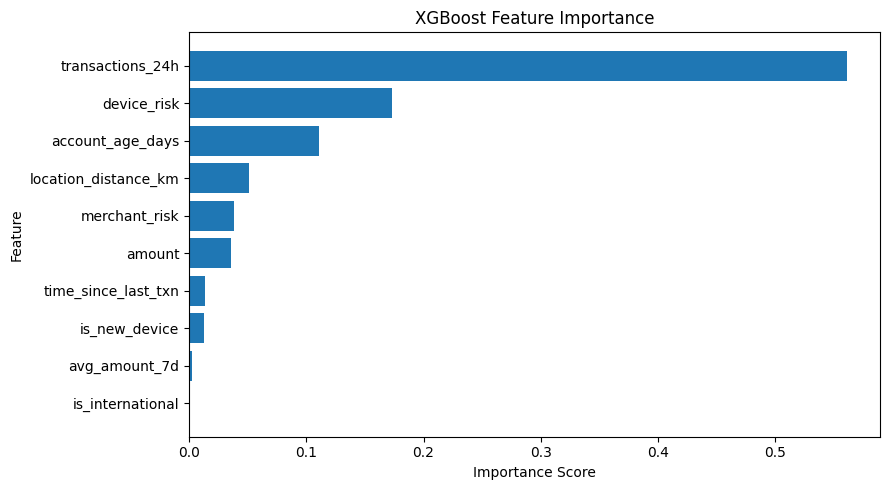

In [9]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

print(feature_importance.round(4).to_string(index=False))

plt.figure(figsize=(9, 5))
plt.barh(
    feature_importance["Feature"].iloc[::-1],
    feature_importance["Importance"].iloc[::-1]
)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

## 9. Interpretation

- **False negative:** a fraudulent transaction is classified as legitimate. This can cause financial loss and allow fraud to continue.
- **False positive:** a legitimate transaction is flagged as fraud. This can inconvenience customers and increase manual-review or operational costs.
- A **lower threshold** generally catches more fraud (higher recall) but can also flag more legitimate transactions.
- Feature importance shows which variables the trained XGBoost model used most strongly for its predictions. It does not prove that a feature causes fraud.

### Important limitation

This repository uses synthetic data for an educational demonstration. It is not the IEEE-CIS Kaggle dataset and the reported scores should not be treated as real-world performance.